# Notebook 07: Stress Analysis using rPPG

This notebook compares the physiological features extracted from facial video (rPPG)
against the ground-truth Blood Volume Pulse (BVP) signal for three experimental tasks:

- Rest
- Speech
- Arithmetic

The objective is to evaluate whether contactless physiological monitoring captures
the same trends as the contact sensor.

| Trial | Task       | Expected Stress |
| ----- | ---------- | --------------- |
| T1    | Rest       | Low             |
| T2    | Speech     | Medium          |
| T3    | Arithmetic | High            |


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from stresscam.features.physiological_features import process_trial

In [2]:
project_root = Path.cwd().parent

data_root = (
    project_root
    / "data"
    / "raw"
    / "UBFC_Phys"
    / "s46"
)

---
### Processing

In [3]:
rest = process_trial(
    data_root / "vid_s46_T1.avi"
)

speech = process_trial(
    data_root / "vid_s46_T2.avi"
)

arithmetic = process_trial(
    data_root / "vid_s46_T3.avi"
)

Processing vid_s46_T1:   0%|          | 0/6325 [00:00<?, ?frame/s]

c:\Users\lason\.conda\envs\stresscam\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Processing vid_s46_T2:   0%|          | 0/6325 [00:00<?, ?frame/s]

Processing vid_s46_T3:   0%|          | 0/6325 [00:00<?, ?frame/s]

---

---
### Feature Table

In [16]:
results = pd.DataFrame(
    [
        {
            "Trial": "Rest",
            "Mean HR": rest["Mean HR"],
            "Mean IBI": rest["Mean IBI"],
            "SDNN": rest["SDNN"],
            "RMSSD": rest["RMSSD"],
            "pNN50": rest["pNN50"],
        },
        {
            "Trial": "Speech",
            "Mean HR": speech["Mean HR"],
            "Mean IBI": speech["Mean IBI"],
            "SDNN": speech["SDNN"],
            "RMSSD": speech["RMSSD"],
            "pNN50": speech["pNN50"],
        },
        {
            "Trial": "Arithmetic",
            "Mean HR": arithmetic["Mean HR"],
            "Mean IBI": arithmetic["Mean IBI"],
            "SDNN": arithmetic["SDNN"],
            "RMSSD": arithmetic["RMSSD"],
            "pNN50": arithmetic["pNN50"],
        },
    ]
)

results

,Trial,Mean HR,Mean IBI,SDNN,RMSSD,pNN50
0,Rest,75.196575,0.803750,0.068680,0.078939,58.108108
1,Speech,85.319619,0.741586,0.199907,0.281935,78.838174
2,Arithmetic,90.171288,0.686292,0.131517,0.177025,67.307692


In [17]:
import matplotlib.pyplot as plt


- Mean Heart Rate

- SDNN

- RMSSD

- pNN50

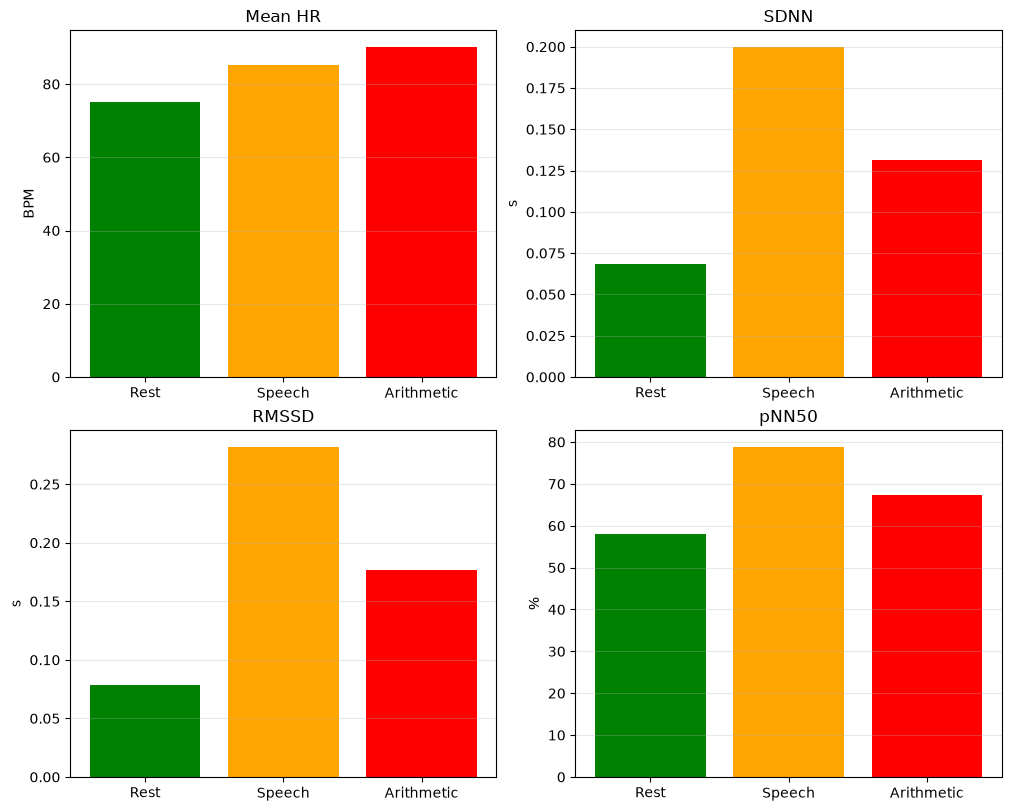

In [18]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10,8),
    constrained_layout=True,
)

features = [
    ("Mean HR","BPM"),
    ("SDNN","s"),
    ("RMSSD","s"),
    ("pNN50","%"),
]

colors = ["green","orange","red"]

for ax,(feature,unit) in zip(axes.flat,features):

    ax.bar(
        results["Trial"],
        results[feature],
        color=colors,
    )

    ax.set_title(feature)
    ax.set_ylabel(unit)

    ax.grid(axis="y",alpha=0.3)

plt.show()

### Validation Table

In [19]:
from stresscam.features.prv import extract_prv_features_from_bvp
def load_bvp(subject_path, trial):
    return (
        pd.read_csv(
            subject_path / f"bvp_s46_T{trial}.csv",
            header=None,
        )
        .squeeze()
        .to_numpy()
    )

In [20]:
bvp_rest = load_bvp(data_root, 1)
bvp_speech = load_bvp(data_root, 2)
bvp_arithmetic = load_bvp(data_root, 3)

In [21]:

video_duration = len(rest["Pulse"]) / rest["FPS"]

bvp_fs = len(bvp_rest) / video_duration

print(f"BVP Sampling Frequency: {bvp_fs:.3f} Hz")

print(bvp_rest.shape)
print(bvp_speech.shape)
print(bvp_arithmetic.shape)

video_duration = len(rest["Pulse"]) / rest["FPS"]

bvp_fs = len(bvp_rest) / video_duration

print(f"BVP Sampling Frequency: {bvp_fs:.3f} Hz")

BVP Sampling Frequency: 63.998 Hz
(11520,)
(11520,)
(11520,)
BVP Sampling Frequency: 63.998 Hz


In [22]:
rest_gt = extract_prv_features_from_bvp(
    bvp_rest,
    fs=bvp_fs,
)

speech_gt = extract_prv_features_from_bvp(
    bvp_speech,
    fs=bvp_fs,
)

arithmetic_gt = extract_prv_features_from_bvp(
    bvp_arithmetic,
    fs=bvp_fs,
)

In [23]:
comparison = pd.DataFrame(
    [
        {
            "Trial": "Rest",
            "Source": "rPPG",
            **{k: rest[k] for k in ["Mean HR", "Mean IBI", "SDNN", "RMSSD", "pNN50"]},
        },
        {
            "Trial": "Rest",
            "Source": "BVP",
            **{k: rest_gt[k] for k in ["Mean HR", "Mean IBI", "SDNN", "RMSSD", "pNN50"]},
        },

        {
            "Trial": "Speech",
            "Source": "rPPG",
            **{k: speech[k] for k in ["Mean HR", "Mean IBI", "SDNN", "RMSSD", "pNN50"]},
        },
        {
            "Trial": "Speech",
            "Source": "BVP",
            **{k: speech_gt[k] for k in ["Mean HR", "Mean IBI", "SDNN", "RMSSD", "pNN50"]},
        },

        {
            "Trial": "Arithmetic",
            "Source": "rPPG",
            **{k: arithmetic[k] for k in ["Mean HR", "Mean IBI", "SDNN", "RMSSD", "pNN50"]},
        },
        {
            "Trial": "Arithmetic",
            "Source": "BVP",
            **{k: arithmetic_gt[k] for k in ["Mean HR", "Mean IBI", "SDNN", "RMSSD", "pNN50"]},
        },
    ]
)

comparison

,Trial,Source,Mean HR,Mean IBI,SDNN,RMSSD,pNN50
0,Rest,rPPG,75.196575,0.803750,0.068680,0.078939,58.108108
1,Rest,BVP,75.214101,0.804182,0.075547,0.104250,42.792793
2,Speech,rPPG,85.319619,0.741586,0.199907,0.281935,78.838174
3,Speech,BVP,83.069093,0.759090,0.175742,0.249147,80.000000
4,Arithmetic,rPPG,90.171288,0.686292,0.131517,0.177025,67.307692
5,Arithmetic,BVP,89.860519,0.687158,0.127103,0.163390,39.615385


In [24]:
def plot_signal_overlay(
    trial_name,
    rppg_signal,
    bvp_signal,
    rppg_fs,
    bvp_fs,
    start_sec=60,
    duration=10,
    ax=None,
):
    """
    Plot a time-aligned comparison between recovered rPPG and
    ground-truth BVP for a selected time window.
    """

    import numpy as np
    from scipy.signal import resample

    # Window indices
    r_start = int(start_sec * rppg_fs)
    r_end = int((start_sec + duration) * rppg_fs)

    b_start = int(start_sec * bvp_fs)
    b_end = int((start_sec + duration) * bvp_fs)

    rppg = rppg_signal[r_start:r_end]
    bvp = bvp_signal[b_start:b_end]

    # Match lengths
    bvp = resample(bvp, len(rppg))

    # Normalize for visualization
    rppg = (rppg - np.mean(rppg)) / np.std(rppg)
    bvp = (bvp - np.mean(bvp)) / np.std(bvp)

    t = np.arange(len(rppg)) / rppg_fs + start_sec

    if ax is None:
        fig, ax = plt.subplots(figsize=(10,3))

    ax.plot(
        t,
        rppg,
        color="black",
        linewidth=1.8,
        label="rPPG",
    )

    ax.plot(
        t,
        bvp,
        color="red",
        linewidth=1.3,
        alpha=0.8,
        label="Ground Truth BVP",
    )

    ax.set_title(trial_name)
    ax.set_ylabel("Normalized Amplitude")

    ax.grid(True, alpha=0.3)

    return ax

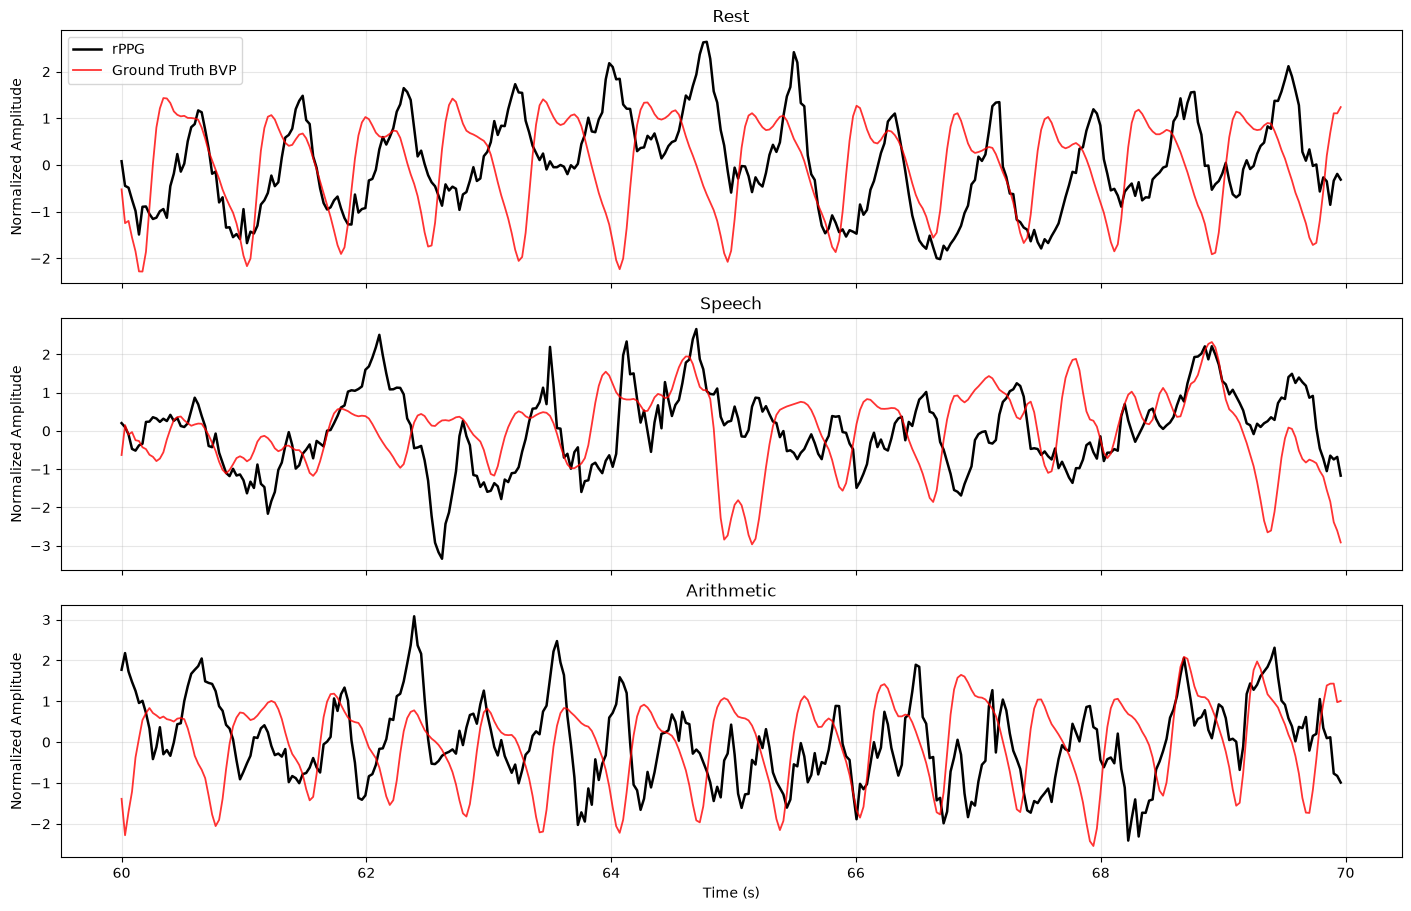

In [25]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,9),
    sharex=True,
    constrained_layout=True,
)

plot_signal_overlay(
    "Rest",
    rest["Pulse"],
    bvp_rest,
    rest["FPS"],
    bvp_fs,
    ax=axes[0],
)

plot_signal_overlay(
    "Speech",
    speech["Pulse"],
    bvp_speech,
    speech["FPS"],
    bvp_fs,
    ax=axes[1],
)

plot_signal_overlay(
    "Arithmetic",
    arithmetic["Pulse"],
    bvp_arithmetic,
    arithmetic["FPS"],
    bvp_fs,
    ax=axes[2],
)

axes[2].set_xlabel("Time (s)")
axes[0].legend()

plt.show()

### Validation Plot

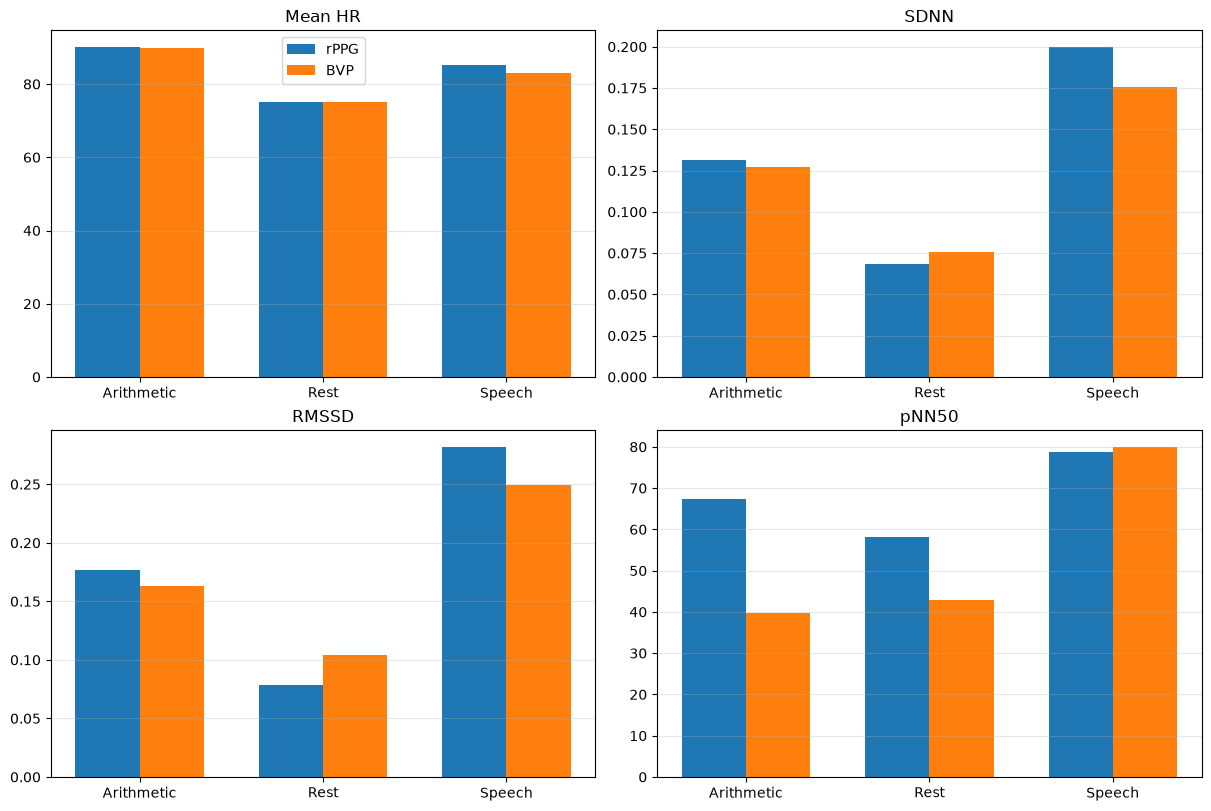

In [26]:
import numpy as np

features = [
    "Mean HR",
    "SDNN",
    "RMSSD",
    "pNN50",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8),
    constrained_layout=True,
)

for ax, feature in zip(axes.flat, features):

    pivot = comparison.pivot(
        index="Trial",
        columns="Source",
        values=feature,
    )

    x = np.arange(len(pivot.index))
    width = 0.35

    ax.bar(
        x - width/2,
        pivot["rPPG"],
        width,
        label="rPPG",
    )

    ax.bar(
        x + width/2,
        pivot["BVP"],
        width,
        label="BVP",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)

    ax.set_title(feature)

    ax.grid(axis="y",alpha=0.3)

axes[0,0].legend()

plt.show()

#### **HR Trend**

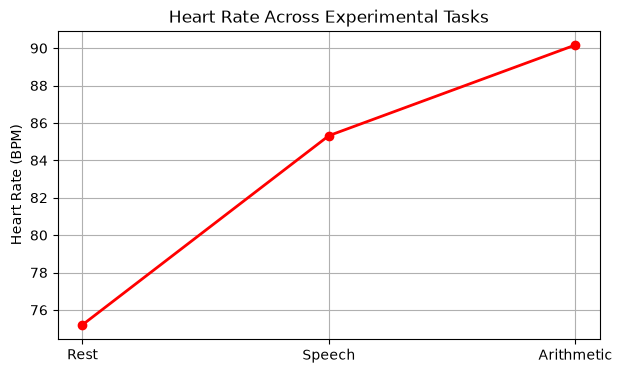

In [27]:
plt.figure(figsize=(7,4))

plt.plot(
    results["Trial"],
    results["Mean HR"],
    marker="o",
    linewidth=2,
    color="red",
)

plt.ylabel("Heart Rate (BPM)")
plt.title("Heart Rate Across Experimental Tasks")

plt.grid(True)

plt.show()

### **Observations**

• Heart rate increased from Rest → Speech → Arithmetic.

• Mean IBI decreased with increasing task difficulty.

• The recovered rPPG closely matched the ground-truth BVP for
  Mean HR, Mean IBI, SDNN and RMSSD.

• pNN50 showed larger differences, indicating higher sensitivity
  to small peak timing variations.

• These results demonstrate that the proposed pipeline can recover
  physiologically meaningful information from facial video.